In [2]:
import seaborn as sns
import matplotlib.pyplot as plt 
import os 
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [3]:
os.listdir("../input/")

['StudentsPerformance.csv']

In [93]:
filename = "../input/StudentsPerformance.csv"
score_df = pd.read_csv(filename)
score_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [94]:
score_df.rename(columns={"race/ethnicity":"ethnicity","parental level of education":"parent_education"
                    ,"math score":"math","reading score":"reading","writing score":"writing",
                    "test preparation course":"pre"},inplace=True)
score_df.head()

,gender,ethnicity,parent_education,lunch,pre,math,reading,writing
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [95]:
score_df.dtypes

gender              object
ethnicity           object
parent_education    object
lunch               object
pre                 object
math                 int64
reading              int64
writing              int64
dtype: object

In [96]:
score_df.shape

(1000, 8)

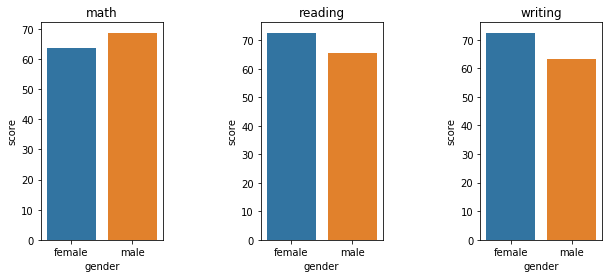

In [97]:
fig, ax = plt.subplots()
fig.subplots_adjust(hspace=0.8, wspace=0.8, left = 0.2, right = 1.5)
for idx in range(3):
    plt.subplot(1,3, idx+1)
    gender_df = score_df.groupby("gender")[list(score_df.columns[-3:])[idx]].describe()
    sns.barplot(gender_df.index, gender_df.loc[:,"mean"].values)
    plt.ylabel("score")
    plt.title(list(score_df.columns[-3:])[idx])
    
plt.show()

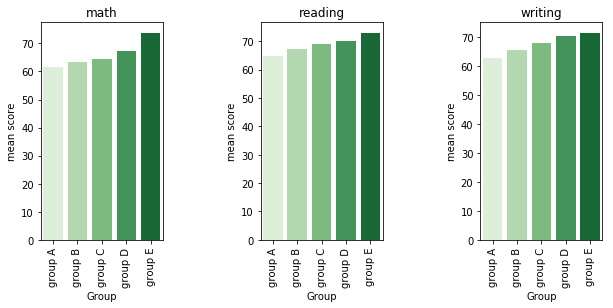

In [98]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
fig.subplots_adjust(hspace=0.8, wspace=0.8, left = 0.2, right = 1.5)
for idx in range(3):
    plt.subplot(1,3, idx+1)
    ethn_df = score_df.groupby("ethnicity")[list(score_df.columns[-3:])[idx]].mean()
    sns.barplot(x=ethn_df.index, y = ethn_df.values, palette = "Greens")
    plt.xlabel("Group")
    plt.ylabel("mean score")
    plt.xticks(rotation=90)
    plt.title(list(score_df.columns[-3:])[idx])
plt.show()

In [99]:
# Numerical columns
numerical_columns = score_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Non-numerical columns
non_numerical_columns = score_df.select_dtypes(include=['object']).columns.tolist()

# Display the numerical and non-numerical columns
print("Categorical Columns:", non_numerical_columns)
print("Numerical Columns:", numerical_columns)
print("\nUnique values in categorical columns:")
for col in non_numerical_columns:
    print(f"Column: {col}")
    print(f"Unique Values: {score_df[col].unique()}")
    print("\n")


Categorical Columns: ['gender', 'ethnicity', 'parent_education', 'lunch', 'pre']
Numerical Columns: ['math', 'reading', 'writing']

Unique values in categorical columns:
Column: gender
Unique Values: ['female' 'male']


Column: ethnicity
Unique Values: ['group B' 'group C' 'group A' 'group D' 'group E']


Column: parent_education
Unique Values: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


Column: lunch
Unique Values: ['standard' 'free/reduced']


Column: pre
Unique Values: ['none' 'completed']




In [100]:
def plot_categorical_distribution(column_name):
    plt.figure(figsize=(12, 5))
    
    # --- Bar Chart ---
    plt.subplot(1, 2, 1)
    sns.countplot(y=column_name, data=score_df, palette='Set2')
    plt.title(f'Distribution of {column_name}')
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{p.get_width()}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', xytext=(10, 0), textcoords='offset points')
    
    sns.despine(left=True, bottom=True)
    
    # --- Pie Chart ---
    plt.subplot(1, 2, 2)
    score_df[column_name].value_counts().plot.pie(
        autopct='%1.1f%%',
        colors=sns.color_palette('Set2'),
        startangle=90,
        explode=[0.05]*score_df[column_name].nunique())
    
    plt.title(f'Percentage Distribution of {column_name}')
    plt.ylabel('')  
    plt.tight_layout()
    plt.show()


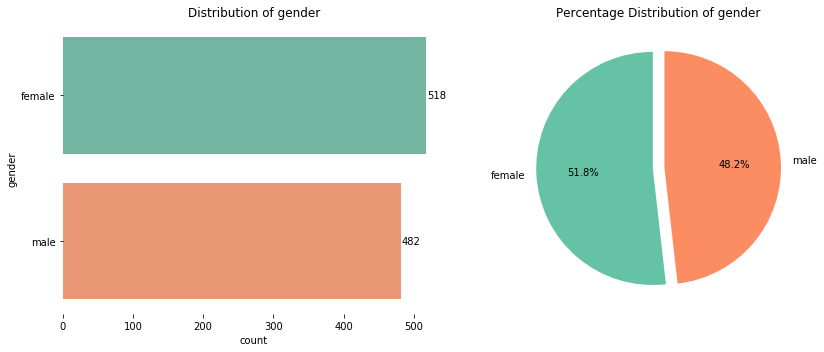

In [101]:
plot_categorical_distribution('gender')

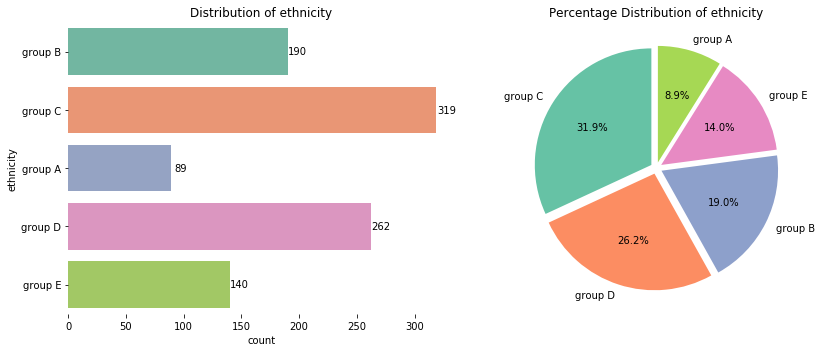

In [102]:
plot_categorical_distribution('ethnicity')

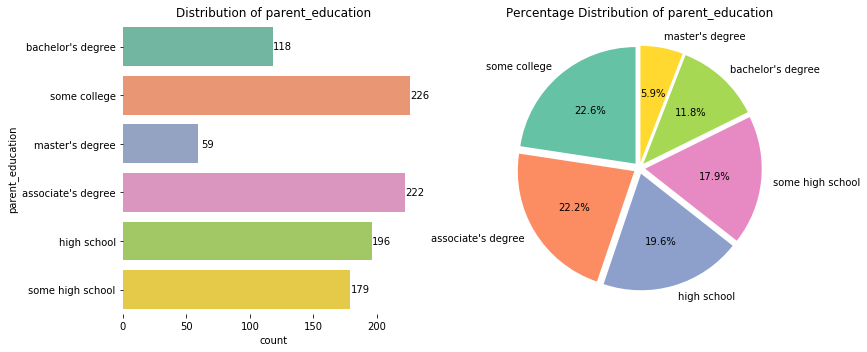

In [103]:
plot_categorical_distribution('parent_education')

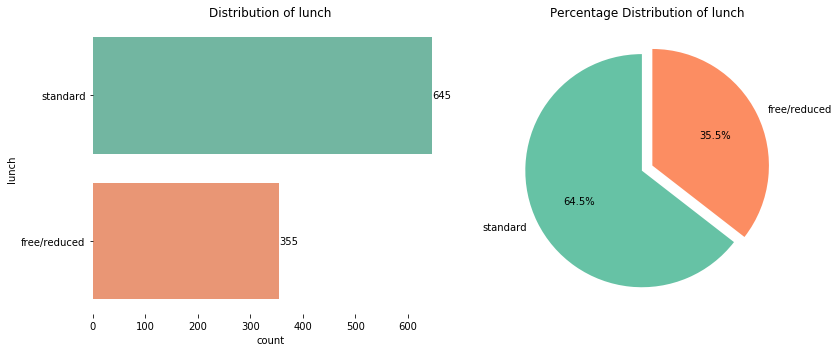

In [104]:
plot_categorical_distribution('lunch')

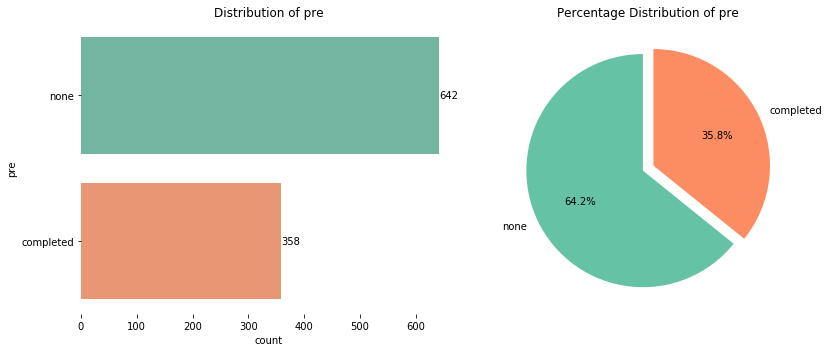

In [105]:
plot_categorical_distribution('pre')

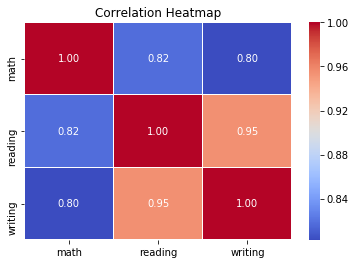

In [106]:
plt.figure(figsize=(6, 4))
sns.heatmap(subset_numerical_columns.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.2)
plt.title('Correlation Heatmap')
plt.show()

In [107]:
subset_numerical_columns = score_df.select_dtypes(include=['float64', 'int64'])

subset_numerical_columns.corr()

,math,reading,writing
math,1.000000,0.817580,0.802642
reading,0.817580,1.000000,0.954598
writing,0.802642,0.954598,1.000000


In [108]:
import numpy as np

num_cols = score_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
outliers_perc = []

print('Percentage of outliers in the columns\n')

def outliers_perc_search(data, features):
    for k, v in data[features].items():
        # Column must be numeric
        if data[k].dtype != 'O':
            q1 = v.quantile(0.25)
            q3 = v.quantile(0.75)
            iqr = q3 - q1
           
            v_col = v[(v <= q1 - 1.5 * iqr) | (v >= q3 + 1.5 * iqr)]
            perc = np.shape(v_col)[0] * 100.0 / np.shape(data)[0]
            out_tuple = (k, int(perc))
            outliers_perc.append(out_tuple)
            print("Column %s outliers = %.1f%%" % (k, perc))
outliers_perc_search(score_df, num_cols)


Percentage of outliers in the columns

Column math outliers = 1.0%
Column reading outliers = 0.8%
Column writing outliers = 0.5%


In [109]:
# Calculate total score by summing up math, reading, and writing scores
score_df['total score'] = score_df['math'] + score_df['reading'] + score_df['writing']

# Calculate average score
score_df['average score'] = score_df['total score'] / 3

# Display the updated dataframe with new columns
score_df[['math', 'reading', 'writing', 'total score', 'average score']].head()

,math,reading,writing,total score,average score
0,72,72,74,218,72.666667
1,69,90,88,247,82.333333
2,90,95,93,278,92.666667
3,47,57,44,148,49.333333
4,76,78,75,229,76.333333


In [110]:
average_scores_by_gender = score_df.groupby('gender').agg(
    avg_reading_score=('reading', 'mean'),
    avg_writing_score=('writing', 'mean'),
    avg_math_score=('math', 'mean'),
    avg_overall_score=('average score', 'mean')
).reset_index()

# Display the table
display(average_scores_by_gender)

,gender,avg_reading_score,avg_writing_score,avg_math_score,avg_overall_score
0,female,72.608108,72.467181,63.633205,69.569498
1,male,65.473029,63.311203,68.728216,65.837483


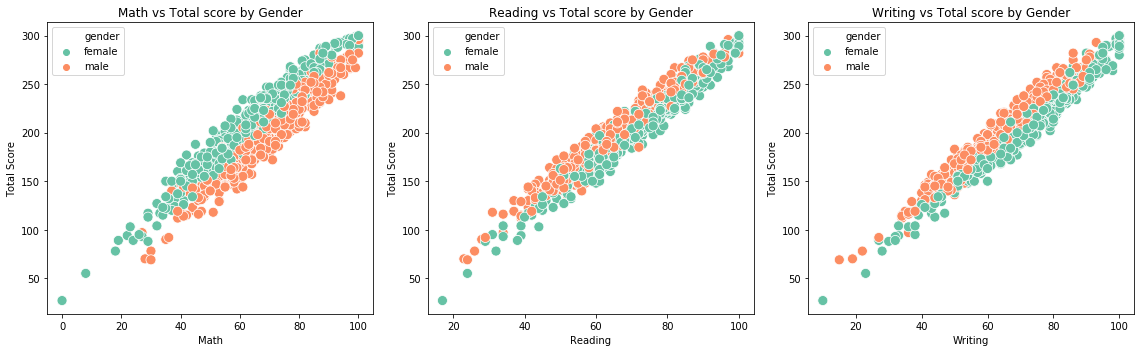

In [111]:
subjects = ['math', 'reading', 'writing']

# Scatter plot for each subject with gender and total score
plt.figure(figsize=(16, 5))

for i, subject in enumerate(subjects, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=subject, y='total score', hue='gender', data=score_df, palette='Set2', s=100)
    plt.title(f'{subject.capitalize()} vs Total score by Gender')
    plt.xlabel(subject.capitalize())
    plt.ylabel('Total Score')

plt.tight_layout()
plt.show()

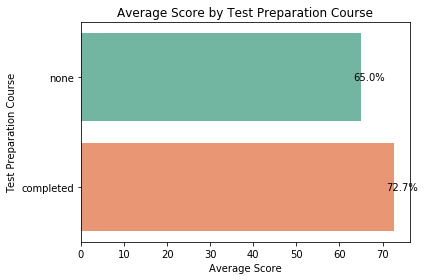

In [112]:
plt.figure(figsize=(6, 4))
sns.barplot(y='pre', x='average score', data=score_df, ci=None, palette='Set2')

# Add percentage labels on top of each bar
for p in plt.gca().patches:
    percentage = f'{(p.get_width() / score_df["average score"].max()) * 100:.1f}%'
    plt.gca().annotate(percentage, (p.get_width(), p.get_y() + p.get_height() / 2), 
                       ha='center', va='center', xytext=(8, 0), textcoords='offset points')

plt.title('Average Score by Test Preparation Course')
plt.xlabel('Average Score')
plt.ylabel('Test Preparation Course')
plt.tight_layout()
plt.show()


In [113]:
score_df

,gender,ethnicity,parent_education,lunch,pre,math,reading,writing,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


In [45]:
from sklearn.preprocessing import LabelEncoder

df_model = score_df.copy()

categorical_cols = ['gender', 'ethnicity', 'parent_education', 'lunch', 'pre']
le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
df_model


,gender,ethnicity,parent_education,lunch,pre,math,reading,writing,total score,average score,classification
0,0,1,1,1,1,72,72,74,218,72.666667,0
1,0,2,4,1,0,69,90,88,247,82.333333,7
2,0,1,3,1,1,90,95,93,278,92.666667,2
3,1,0,0,0,1,47,57,44,148,49.333333,5
4,1,2,4,1,1,76,78,75,229,76.333333,7
...,...,...,...,...,...,...,...,...,...,...,...
995,0,4,3,1,0,88,99,95,282,94.000000,2
996,1,2,2,0,1,62,55,55,172,57.333333,1
997,0,2,2,0,0,59,71,65,195,65.000000,4
998,0,3,4,1,0,68,78,77,223,74.333333,0


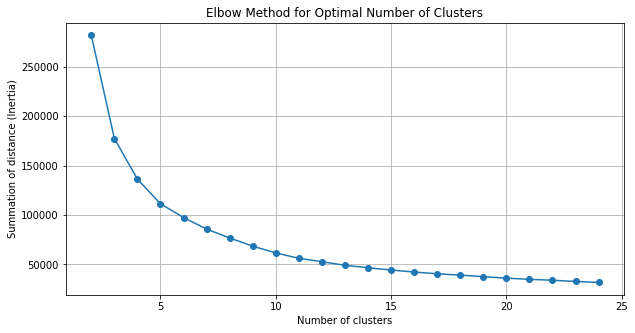

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

numeric_cols = ['math', 'reading', 'writing']
kmeans_dis = []
for n_clusters in range(2, 25):
    kmeans = KMeans(
        init="k-means++", 
        n_clusters=n_clusters, 
        n_init=20, 
        random_state=42
    )
    kmeans.fit(df_model[numeric_cols])  
    kmeans_dis.append(kmeans.inertia_)


plt.figure(figsize=(10,5))
plt.plot(range(2,25), kmeans_dis, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Summation of distance (Inertia)")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.grid(True)
plt.show()


In [78]:
from sklearn.cluster import KMeans

numeric_cols = ['math', 'reading', 'writing']  
kmeans = KMeans(init="k-means++", n_clusters=5, random_state=42)
kmeans.fit(df_model[numeric_cols])
df_model['classification'] = kmeans.labels_

df_model.head(10)


,gender,ethnicity,parent_education,lunch,pre,math,reading,writing,total score,average score,classification
0,0,1,1,1,1,72,72,74,218,72.666667,0
1,0,2,4,1,0,69,90,88,247,82.333333,2
2,0,1,3,1,1,90,95,93,278,92.666667,2
3,1,0,0,0,1,47,57,44,148,49.333333,1
4,1,2,4,1,1,76,78,75,229,76.333333,0
5,0,1,0,1,1,71,83,78,232,77.333333,0
6,0,1,4,1,0,88,95,92,275,91.666667,2
7,1,1,4,0,1,40,43,39,122,40.666667,4
8,1,3,2,0,0,64,64,67,195,65.000000,3
9,0,1,2,0,1,38,60,50,148,49.333333,1


In [79]:
score_cols = ['math', 'reading', 'writing', 'total score', 'average score']
class_df = df_model.groupby("classification")[score_cols].mean()
class_df


,math,reading,writing,total score,average score
classification,,,,,
0,73.782288,77.409594,76.328413,227.520295,75.840098
1,52.669725,54.770642,52.811927,160.252294,53.417431
2,86.054545,89.690909,89.163636,264.909091,88.303030
3,63.675958,66.613240,66.020906,196.310105,65.436702
4,36.237288,39.559322,37.220339,113.016949,37.672316


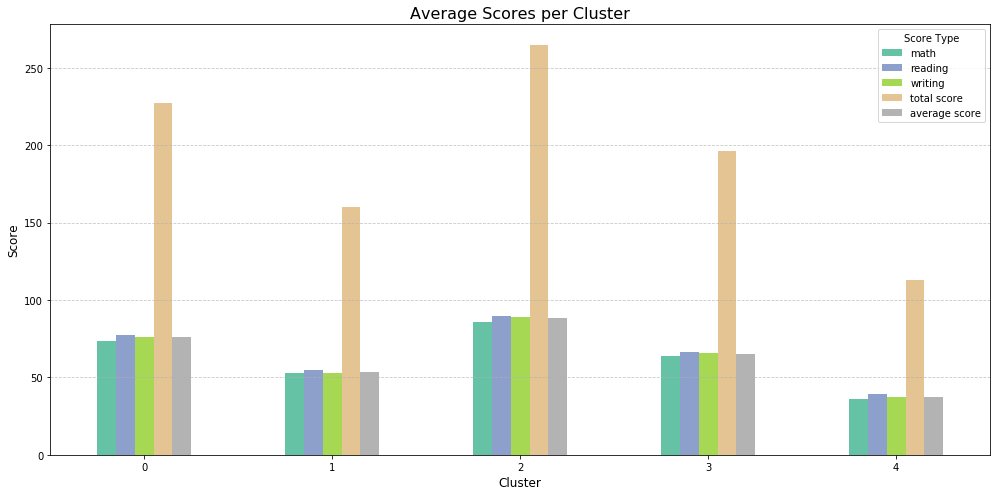

In [80]:
score_cols = ['math', 'reading', 'writing', 'total score', 'average score']
class_df[score_cols].plot(kind='bar', figsize=(14,7), colormap='Set2')
plt.title("Average Scores per Cluster", fontsize=16)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Score Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [81]:
print(class_df.columns)


Index(['math', 'reading', 'writing', 'total score', 'average score'], dtype='object')


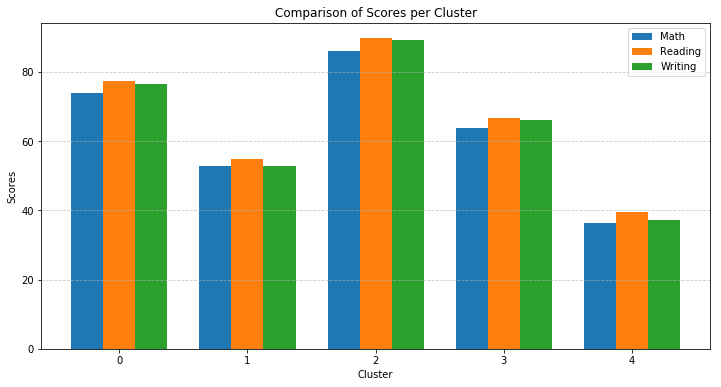

In [82]:
import matplotlib.pyplot as plt
import numpy as np

subjects = ['math', 'reading', 'writing']

ind = np.arange(len(class_df))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

rects1 = ax.bar(ind - width, class_df['math'], width, label='Math')
rects2 = ax.bar(ind, class_df['reading'], width, label='Reading')
rects3 = ax.bar(ind + width, class_df['writing'], width, label='Writing')

ax.set_xlabel('Cluster')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Scores per Cluster')
ax.set_xticks(ind)
ax.set_xticklabels(class_df.index)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [83]:
class_df["total_ave_score"] = (class_df.math + class_df.reading + class_df.writing)/3
rank = class_df["total_ave_score"].sort_values(ascending = False)
rank.index

Int64Index([2, 0, 3, 1, 4], dtype='int64', name='classification')

In [84]:
rank

classification
2    88.303030
0    75.840098
3    65.436702
1    53.417431
4    37.672316
Name: total_ave_score, dtype: float64

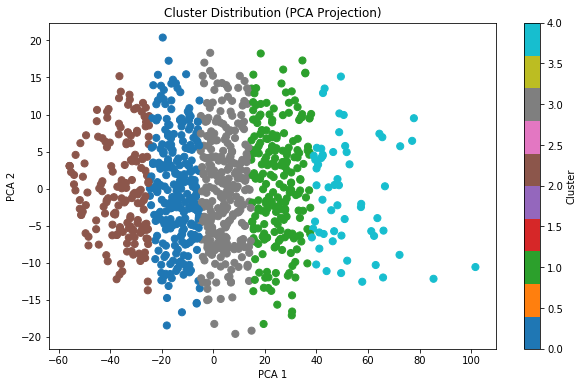

Silhouette Score: 0.332


In [89]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
numeric_cols = ['math', 'reading', 'writing']
X = df_model[numeric_cols]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_model['classification'], cmap='tab10', s=50)
plt.colorbar(label='Cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Cluster Distribution (PCA Projection)')
plt.show()

score = silhouette_score(X, df_model['classification'])
print(f'Silhouette Score: {score:.3f}')


n_clusters = 2, Silhouette Score = 0.473
n_clusters = 3, Silhouette Score = 0.406
n_clusters = 4, Silhouette Score = 0.352
n_clusters = 5, Silhouette Score = 0.332
n_clusters = 6, Silhouette Score = 0.298
n_clusters = 7, Silhouette Score = 0.305
n_clusters = 8, Silhouette Score = 0.302
n_clusters = 9, Silhouette Score = 0.308
n_clusters = 10, Silhouette Score = 0.314

 clusters: 2 Silhouette Score = 0.473


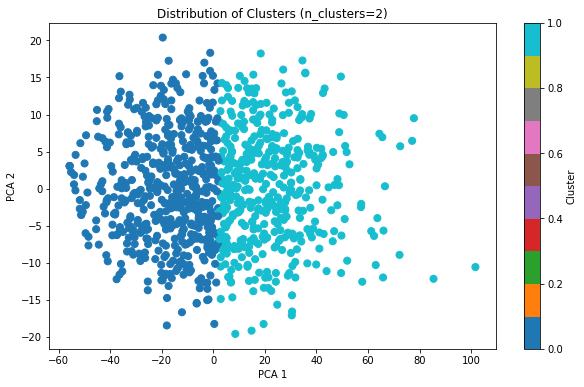

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
numeric_cols = ['math', 'reading', 'writing']
X = df_model[numeric_cols]

best_score = -1
best_k = 0
best_labels = None
best_X = X.copy()

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"n_clusters = {k}, Silhouette Score = {score:.3f}")
    if score > best_score:
        best_score = score
        best_k = k
        best_labels = labels
        best_X = X.copy()

print(f"\n clusters: {best_k} Silhouette Score = {best_score:.3f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(best_X)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=best_labels, cmap='tab10', s=50)
plt.colorbar(label='Cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'Distribution of Clusters (n_clusters={best_k})')
plt.show()


In [116]:
def assign_grade(avg_score):
    if avg_score >= 90:
        return 'A'
    elif avg_score >= 80:
        return 'B'
    elif avg_score >= 70:
        return 'C'
    elif avg_score >= 60:
        return 'D'
    else:
        return 'F'

# Apply the grading function to the 'average score' column
score_df['grade'] = score_df['average score'].apply(assign_grade)

# Display the updated DataFrame with the new 'grade' column
print(score_df[['math', 'reading', 'writing', 'average score', 'grade']].head())

   math  reading  writing  average score grade
0    72       72       74      72.666667     C
1    69       90       88      82.333333     B
2    90       95       93      92.666667     A
3    47       57       44      49.333333     F
4    76       78       75      76.333333     C


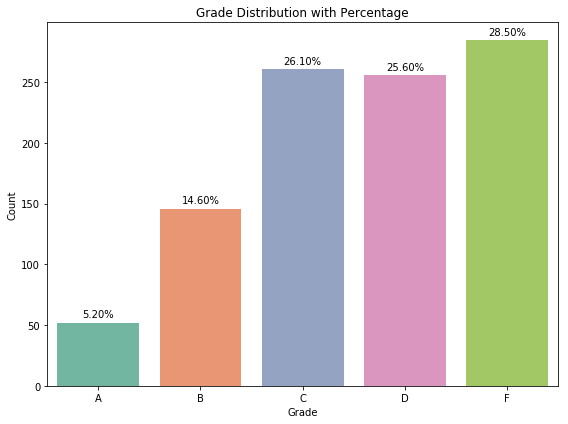

In [117]:
plt.figure(figsize=(8, 6))
sns.countplot(x='grade', data=score_df, palette='Set2', order=['A', 'B', 'C', 'D', 'F'])

# Calculate total number of students for percentage calculation
total_students = len(score_df)

# Add percentage labels on top of bars
ax = plt.gca()
for p in ax.patches:
    percentage = f'{(p.get_height() / total_students) * 100:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.title('Grade Distribution with Percentage')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [119]:
def assign_exam_status(grade):
    if grade in ['A', 'B', 'C', 'D']:
        return 'Pass'
    else:
        return 'Fail'

# Apply the function to create the 'exam_status' column
score_df['exam_status'] = score_df['grade'].apply(assign_exam_status)

# Display the updated DataFrame with the new 'exam_status' column
print(score_df[['math', 'reading', 'writing', 'average score', 'grade', 'exam_status']].head())

   math  reading  writing  average score grade exam_status
0    72       72       74      72.666667     C        Pass
1    69       90       88      82.333333     B        Pass
2    90       95       93      92.666667     A        Pass
3    47       57       44      49.333333     F        Fail
4    76       78       75      76.333333     C        Pass


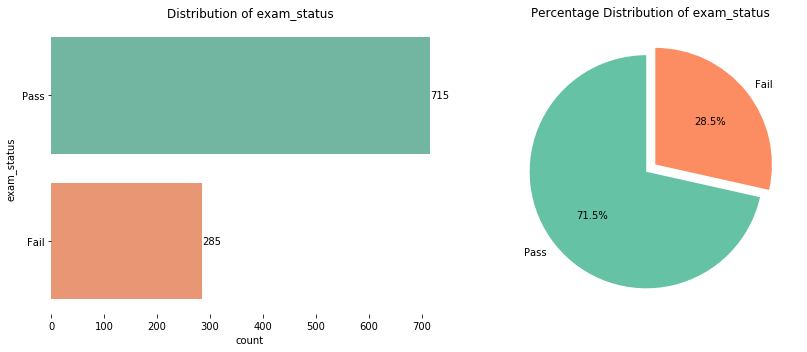

In [120]:
plot_categorical_distribution('exam_status')

In [121]:
score_df

,gender,ethnicity,parent_education,lunch,pre,math,reading,writing,total score,average score,grade,exam_status
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,C,Pass
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,B,Pass
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,A,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,F,Fail
4,male,group C,some college,standard,none,76,78,75,229,76.333333,C,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000,A,Pass
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333,F,Fail
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000,D,Pass
998,female,group D,some college,standard,completed,68,78,77,223,74.333333,C,Pass


In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
cols = ['gender', 'ethnicity', 'parent_education', 'lunch', 'pre', 
        'math', 'reading', 'writing', 'exam_status']
df_clean = score_df[cols]
le = LabelEncoder()
for col in ['gender', 'ethnicity', 'parent_education', 'lunch', 'pre', 'exam_status']:
    df_clean[col] = le.fit_transform(df_clean[col])
X = df_clean.drop('exam_status', axis=1)
y = df_clean['exam_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95        62
           1       0.99      0.96      0.98       138

    accuracy                           0.97       200
   macro avg       0.96      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cols = ['gender', 'ethnicity', 'parent_education', 'lunch', 'pre', 
        'math', 'reading', 'writing', 'exam_status']

scaler = StandardScaler()
X[['math','reading','writing']] = scaler.fit_transform(X[['math','reading','writing']])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        62
           1       0.99      0.99      0.99       138

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


Confusion Matrix:
 [[ 61   1]
 [  1 137]]
